# Simple ARIMA Model for Non-Seasonal Time Series Forecasting

Our goal in this challenge is to apply the fundamental concepts of time series analysis to univariate data.

In these challenges we will follow these steps:
1. loading and visualizing the data;
2. training our models and making predictions;

##  1. Data Loading
Let's start by loading the time series we'll use in the challenge. Run the line below to download the dataset as a CSV file, then load the CSV into a DataFrame.

In [21]:
!curl https://d32aokrjazspmn.cloudfront.net/materials/www_usage.csv > data/www_usage.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   377  100   377    0     0   3857      0 --:--:-- --:--:-- --:--:--  3886


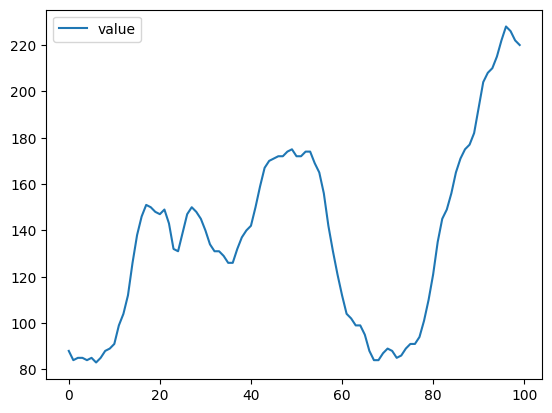

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data/www_usage.csv', names=['value'], header=0)
y = df.value

df.plot();

This abstract time series doesn't appear to be seasonal, but it shows an increasing trend and somewhat "sticky" (i.e., slightly auto-regressive) properties. Therefore it could be a good candidate for Auto-Regressive Moving Average (ARIMA) models.

## 2. Building an ARIMA Model
We will try to forecast the data using ARIMA models (Auto Regressive Integrated Moving Average).

To do this we will need to:
1. find how to make the time series stationary (the I in ARIMA)
2. find the auto-regressive (AR) part
3. find the moving average (MA) part
4. Fit
5. Evaluate performance

### Step 1 - Ensuring Stationarity

ARIMA models can only be applied to "stationary" time series.

👉 Check its stationarity definitively using the [`Augmented Dickey-Fuller test`](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.adfuller.html), especially the p-value

In [23]:
from statsmodels.tsa.stattools import adfuller

print('p-value: ', adfuller(y)[1])

p-value:  0.12441935447109442


For 95% confidence in stationarity, the p-value should be less than 0.05.
If the p-value is greater than 0.05, we cannot reject the null hypothesis (null hypothesis = "the process is not stationary").

If the time series is not stationary, it needs to be made stationary through **differencing**.
- This means taking the difference between each value and the previous value (*first difference*).
- If you want the *second difference*, repeat the operation on the differenced series, etc...

👉 Find the minimum differencing order needed to make it stationary (plot the curves to visualize and print the adfuller p-values to be sure)

<details>
    <summary>Hint</summary>

`pd.Series.diff`
</details>

In [24]:
# 0 diff
print('p-value: ', adfuller(y)[1])

p-value:  0.12441935447109442


In [25]:
# 1 diff
print('p-value: ', adfuller(y.diff(1).fillna(0))[1])

p-value:  0.07202830223065516


In [26]:
# 2 diff
print('p-value: ', adfuller(y.diff(1).diff(1).fillna(0))[1])

p-value:  1.9962474849713924e-17


Here we have a close call between one and two differencing orders. Over-differencing time series can also degrade the performance of your ARIMA models. Let's take a closer look:

👉 Plot the autocorrelation chart ([`plot_acf`](https://www.statsmodels.org/stable/generated/statsmodels.graphics.tsaplots.plot_acf.html)) for both the 1st and 2nd differencing orders.

(💡Pro tip: avoid duplication of statsmodels charts by adding `;` at the end of each statsmodels plot instance or calling `plt.show()`)

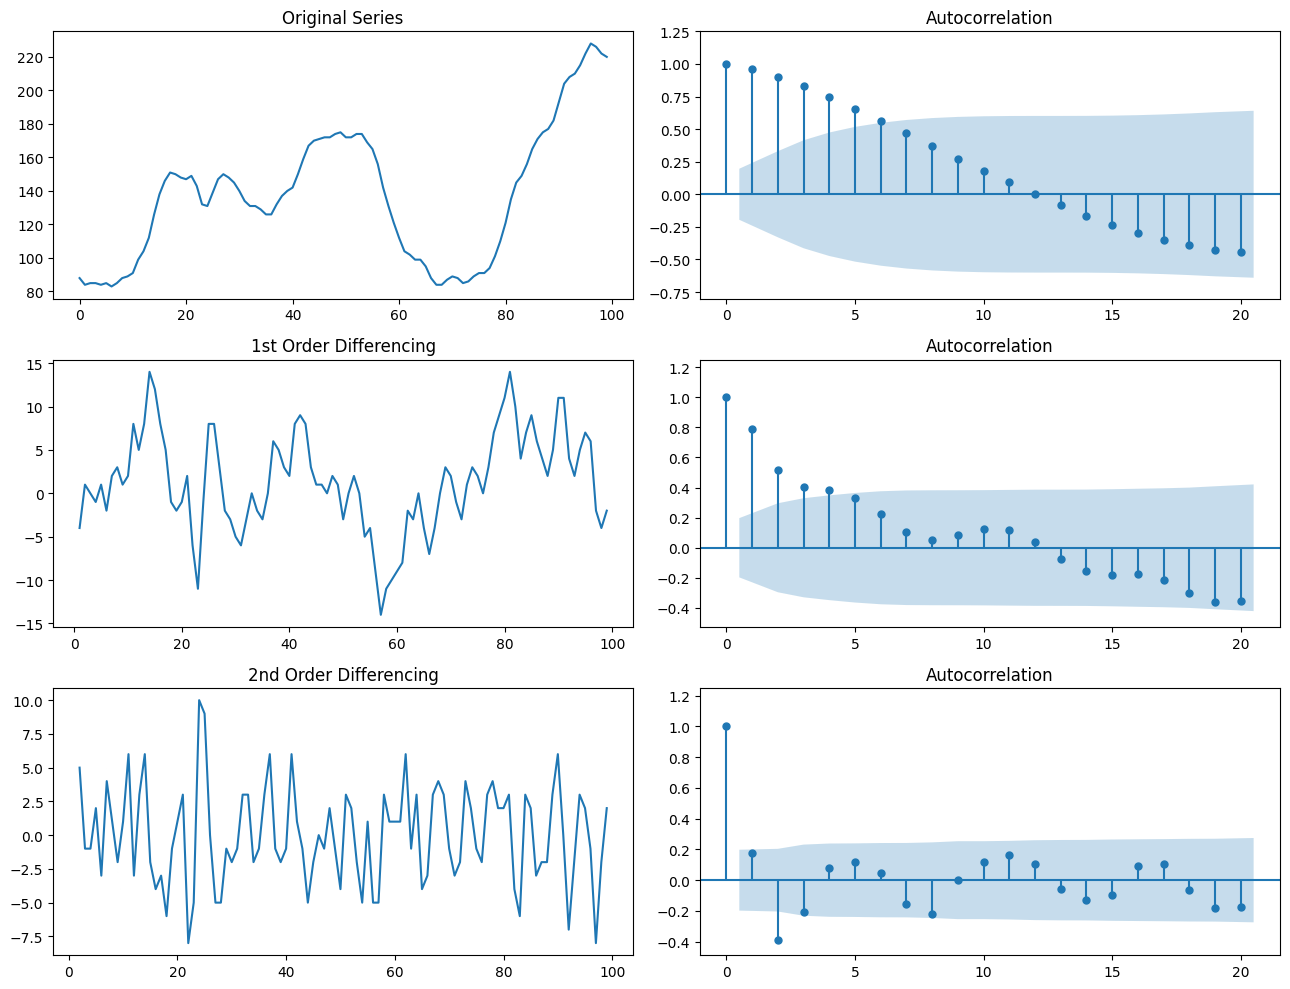

In [27]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Original Series
fig, axes = plt.subplots(3, 2, figsize=(13,10))
axes[0, 0].plot(y); axes[0, 0].set_title('Original Series')
plot_acf(y, auto_ylims=True,ax=axes[0, 1])

# 1 diff
axes[1, 0].plot(y.diff()); axes[1, 0].set_title('1st Order Differencing')
plot_acf(y.diff().dropna(), auto_ylims=True,ax=axes[1, 1])

# 2 diff
axes[2, 0].plot(y.diff().diff()); axes[2, 0].set_title('2nd Order Differencing')
plot_acf(y.diff().diff().dropna(), auto_ylims=True, ax=axes[2, 1])

plt.tight_layout()

In our "second order difference" autocorrelation plot, the lag 1 coefficient is close to 0 and the second one extends into negative territory. This may indicate that we over-differenced the series. (Remember: we never care about lag 0 which is always equal to 1)

👉 Let's (temporarily) keep only one differencing order and call this series `y_diff` (we can always try more differences later)

In [28]:
y_diff = y.diff().dropna()

We just found the "I" in ARIMA: `d = 1` for 1-difference before being stationary ("I" stands for "integration", "d" is for differencing...)

### Step 2 - Select the AR order (p) and MA order (q)

#### MA($\color{blue}{q}$) = number of lags where the $\color{blue}{ACF}$ of $Y^{\color{green}{(d)}}$ cuts off

The MA order (`q`) can be found by looking at the autocorrelation plot ([`plot_acf`](https://www.statsmodels.org/stable/generated/statsmodels.graphics.tsaplots.plot_acf.html)) applied to `y_diff`.

👉 Determine `q`

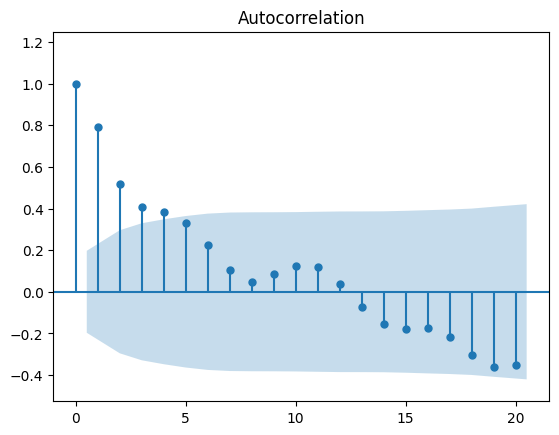

In [29]:
plot_acf(y_diff, auto_ylims=True);

The maximum value we should evaluate for fitting our model seems to be q = 4. However, if we were to use Auto-ARIMA (more details on this later), we'd find that using q=2 gives ideal results, so let's try setting q=2 to start.

When in doubt, choose the simpler model that sufficiently explains Y.

#### AR($\color{red}{p}$) = number of lags where the $\color{red}{PACF}$ of $Y^{\color{green}{(d)}}$ cuts off

The AR order (`p`) can be found by examining the **p**artial autocorrelation plot [`plot_pacf`](https://www.statsmodels.org/stable/generated/statsmodels.graphics.tsaplots.plot_pacf.html) applied to `y_diff`.

(Partial autocorrelation can be thought of as the correlation between a series and its lag after excluding the contributions of intermediate lags. So PACF somehow conveys the "pure" correlation between a lag and the series)

👉 Determine `p`

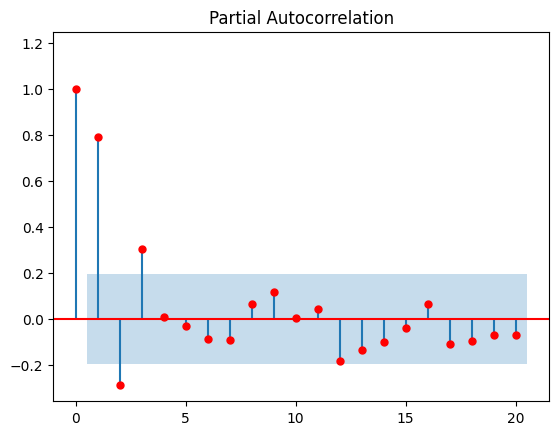

In [30]:
plot_pacf(
    y_diff, 
    method='ywm', 
    c="red", 
    auto_ylims=True
);

We can choose `p = 3` since the first 3 lag terms appear above the significance level, but we could also go with a simpler model with `p = 1`.

### Step 3 - Build the model

Now that you've selected the values of `p`, `d` and `q` for ARIMA,

👉 Build the `arima_model` from `statsmodels`.
- fits the model
- prints the model (`.summary`)

In [31]:
from statsmodels.tsa.arima.model import ARIMA

p = 1
d = 1
q = 2

arima = ARIMA(y, order=(p, d, q), trend='t')
arima_fit = arima.fit()

print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  100
Model:                 ARIMA(1, 1, 2)   Log Likelihood                -253.790
Date:                Sat, 28 Mar 2026   AIC                            517.580
Time:                        19:08:11   BIC                            530.556
Sample:                             0   HQIC                           522.830
                                - 100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             1.1199      1.324      0.846      0.398      -1.476       3.716
ar.L1          0.6352      0.144      4.406      0.000       0.353       0.918
ma.L1          0.5285      0.179      2.959      0.0

☝️ If your p-values are too high, try removing those terms by reducing the corresponding AR or MA coefficients.

You can evaluate the overall performance of your fit by minimizing the [`AIC - Akaike Information Criterion`](https://medium.com/towardsdatascience/the-akaike-information-criterion-c20c8fd832f2) value.

It appears that (1,1,1) ARIMA models have less chance of overfitting (p-values remain low) and maintain a nearly similar AIC score compared to other models.

## 3. Evaluate Model Performance

👉 Visualize your model predictions with the `plot_predict()` method

- Look carefully at the default parameters of the method, especially the `dynamic` parameter.
- Do you think your model would actually perform this well?

In [32]:
from statsmodels.graphics.tsaplots import plot_predict

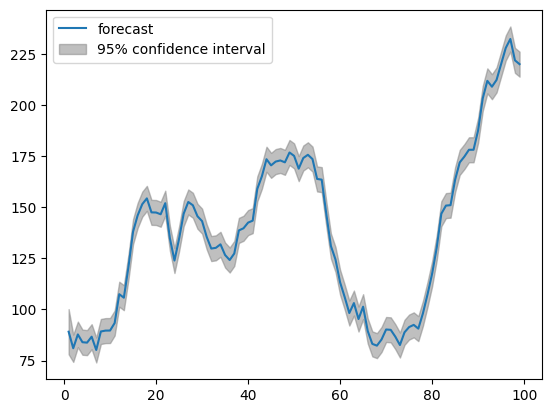

In [33]:
plot_predict(arima_fit, start=1, dynamic=False);

☝️ `dynamic=False` uses all available `y` values to predict `y_pred`, which makes your ARIMA forecast use up to $y_{t-1}$ to predict $y_t$. In reality, you don't have access to all `y`, especially if you want to forecast several intervals into the future.

👉 Try using `dynamic=True` to draw a forecast predicting the _last 15 values_ in a scenario where the model _only has access to data up to 85_. That is, the model:
- predicts 86 based on real [1...85]
- then predicts 87 based on its previously forecast value for 86 _plus_ [1...85]
- etc... iteratively up to 100

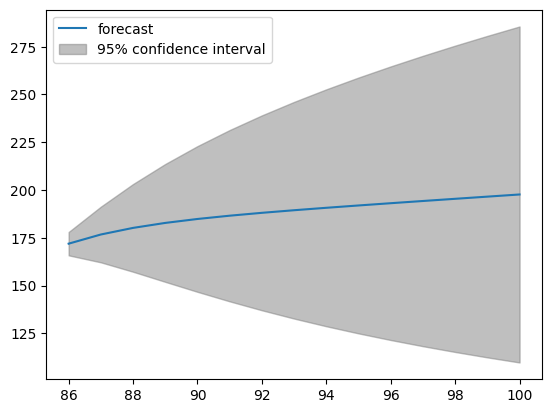

In [34]:
plot_predict(arima_fit, start=86, end=100, dynamic=True);

☝️ This is still _not_ a _real_ forecast! Why?

<details>
    <summary>Answer</summary>

Our model "saw" the full `y_true` series during the fitting stage!
</details>

### 3.1 Out-of-Sample Forecasts (true "future")

👉 Create a train-test split by keeping only the last 15 data points for the test set, and train your ARIMA only on the training set.

In [35]:
y_train = y[:-15]
y_test = y[-15:]

arima = ARIMA(y_train, order=(1, 1, 2), trend='t').fit()

👉 Now we're at step 85 and we've never seen the future:
- Use the `get_forecast()` method on the `arima` model you fitted to "forecast" the next 15 data points (i.e., beyond the end of your training dataset)

The method returns a `PredictionResultsWrapper` object from `statsmodels`.

**💻 Store this result in a variable named `forecast_results`.**

It can be tricky to navigate at first, but here are some hints:
- You can find your predictions in `forecast_results.predicted_mean`
- Your confidence intervals are given by `forecast_results.conf_int()`

In [36]:
forecast_results = arima.get_forecast(steps=15, alpha=0.05)

/Users/yaren/.pyenv/versions/workintech/lib/python3.12/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


In [37]:
forecast = forecast_results.predicted_mean.reset_index(drop=True)
# forecast = arima.forecast(15, alpha=0.05)
conf_int = pd.DataFrame(forecast_results.conf_int().values, columns=['low', 'high'])

👉 Plot the predicted values and also the upper and lower bounds of the 95% uncertainty interval

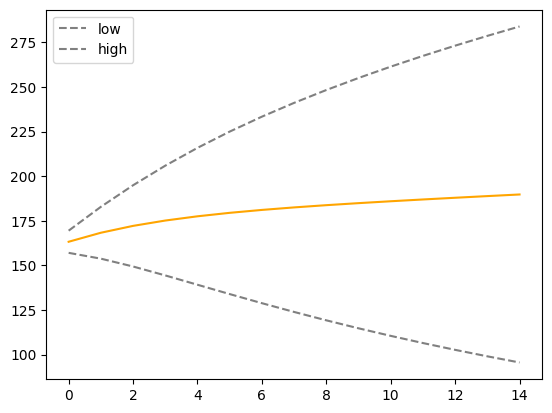

In [38]:
plt.plot(forecast, c='orange')
plt.plot(conf_int['low'], label='low', c='grey', ls='--')
plt.plot(conf_int['high'], label='high', c='grey', ls='--')
plt.legend();

👉 Also try plotting your previous 85 `y` true data points to better understand the model's historical performance

In [39]:
forecast.index = y_test.index
conf_int.index = y_test.index

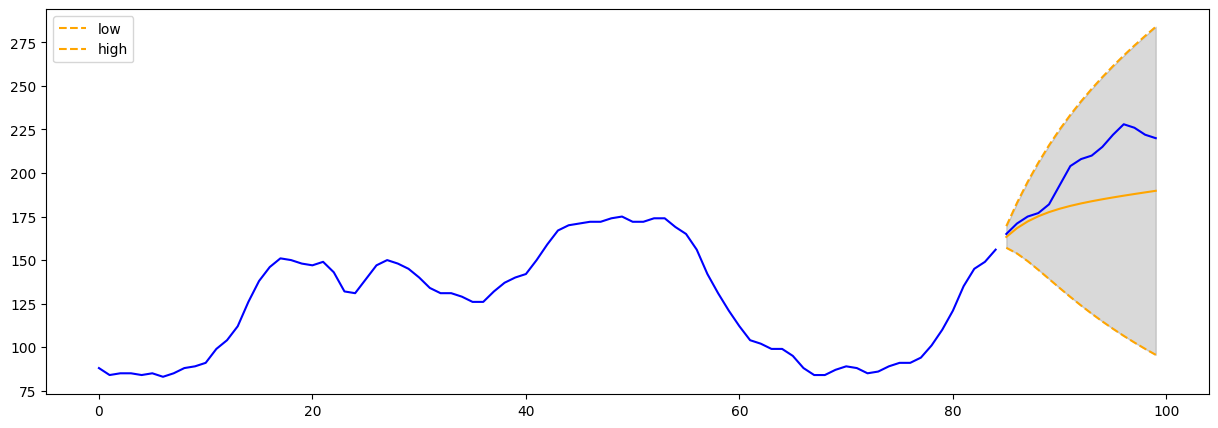

In [40]:
plt.figure(figsize=(15,5))

plt.plot(forecast, c='orange')
plt.plot(conf_int['low'], label='low', c='orange', ls='--')
plt.plot(conf_int['high'], label='high', c='orange', ls='--')
plt.plot(y_train, c='blue')
plt.plot(y_test, c='blue')

plt.legend()
plt.fill_between(y_test.index, conf_int['low'], conf_int['high'], color='k', alpha=.15);

### 3.2 Can you trust your 95% confidence interval? (inference conditions)

👉 Plot the residuals `model.resid` to make sure there are no patterns
- Normal distribution
- Zero mean
- Uniform variance
- No auto-regressive pattern (you can plot_acf the residuals if you want)

Note: residuals are generated by "seeing" all data as in `plot_predict(dynamic=False)`

Also, try plotting a histogram or KDE fit of the residuals to see if the residuals are approximately normally distributed.

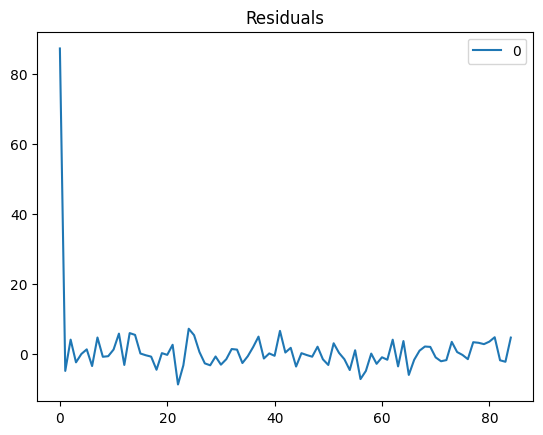

In [41]:
residuals = pd.DataFrame(arima.resid)
residuals.plot(title='Residuals');

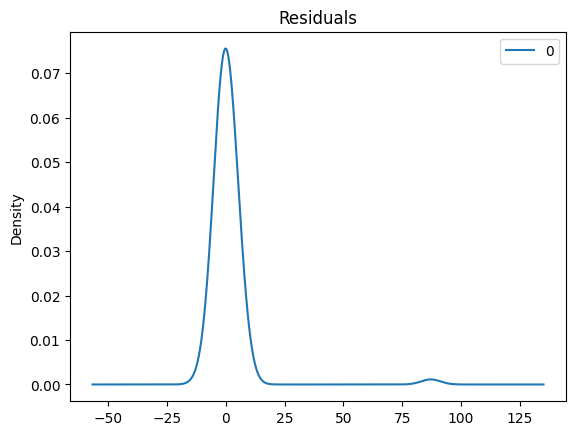

In [42]:
residuals.plot(title='Residuals', kind='kde');

## 3.3 Cross-validated performance metrics

👉 Below are the most common performance metrics for time series

In [43]:
import numpy as np
from statsmodels.tsa.stattools import acf

def forecast_accuracy(y_pred: pd.Series, y_true: pd.Series) -> float:

    mape = np.mean(np.abs(y_pred - y_true)/np.abs(y_true))  # Mean Absolute Percentage Error
    me = np.mean(y_pred - y_true)             # ME
    mae = np.mean(np.abs(y_pred - y_true))    # MAE
    mpe = np.mean((y_pred - y_true)/y_true)   # MPE
    rmse = np.mean((y_pred - y_true)**2)**.5  # RMSE
    corr = np.corrcoef(y_pred, y_true)[0,1]   # Correlation between the Actual and the Forecast
    mins = np.amin(np.hstack([y_pred.values.reshape(-1,1), y_true.values.reshape(-1,1)]), axis=1)
    maxs = np.amax(np.hstack([y_pred.values.reshape(-1,1), y_true.values.reshape(-1,1)]), axis=1)
    minmax = 1 - np.mean(mins/maxs)             # minmax
    acf1 = acf(y_pred-y_true, fft=False)[1]                      # Lag 1 Autocorrelation of Error

    forecast = ({
        'mape':mape,
        'me':me,
        'mae': mae,
        'mpe': mpe,
        'rmse':rmse,
        'acf1':acf1,
        'corr':corr,
        'minmax':minmax
    })

    return forecast

👉 Play with your ARIMA hyperparameters and see the effect on your forecast performance

In [44]:
forecast_accuracy(forecast, y_test)

{'mape': 0.09621163312201977,
 'me': -20.668928861961547,
 'mae': 20.668928861961547,
 'mpe': -0.09621163312201977,
 'rmse': 25.065073357190442,
 'acf1': 0.8751997948399964,
 'corr': 0.9570440295667583,
 'minmax': 0.09621163312201975}

## 4 Grid Search

Try running a Grid Search for (p,d,q) using `pmdarima`. Use at least:
- `test='adf'`
- `trace=True`
- `error_action='ignore'`
- `suppress_warnings=True`

In [45]:
import pmdarima as pm

model = pm.auto_arima(
    y_train,
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    d=None,           # let model determine 'd'
    test='adf',       # using adf test to find optimal 'd'
    trace=True, error_action='ignore',  suppress_warnings=True
)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=449.662, Time=0.01 sec
 ARIMA(1,2,0)(0,0,0)[0]             : AIC=449.569, Time=0.01 sec
 ARIMA(0,2,1)(0,0,0)[0]             : AIC=445.819, Time=0.01 sec
 ARIMA(1,2,1)(0,0,0)[0]             : AIC=445.820, Time=0.01 sec
 ARIMA(0,2,2)(0,0,0)[0]             : AIC=441.300, Time=0.01 sec
 ARIMA(1,2,2)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(0,2,3)(0,0,0)[0]             : AIC=438.613, Time=0.01 sec
 ARIMA(1,2,3)(0,0,0)[0]             : AIC=440.036, Time=0.01 sec
 ARIMA(0,2,3)(0,0,0)[0] intercept   : AIC=440.231, Time=0.01 sec

Best model:  ARIMA(0,2,3)(0,0,0)[0]          
Total fit time: 0.118 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   85
Model:               SARIMAX(0, 2, 3)   Log Likelihood                -215.307
Date:                Sat, 28 Mar 2026   AIC                   

## (Optional) Cross-Validate Your Model's Performance

In practice, results and Grid Search should always be cross-validated:

Feel free to use [`sklearn.model_selection.TimeSeriesSplit`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html) to create contiguous K-folds to really evaluate your model's performance and find the best hyperparameters after cross-validation.

<img src='https://scikit-learn.org/stable/_images/sphx_glr_plot_cv_indices_013.png'>

**ARIMA - Cross-Validation using TimeSeriesSplit + Grid Search**

In [48]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
import itertools
from statsmodels.tsa.statespace.sarimax import SARIMAX

range_p = [0, 1, 2]
range_d = [1, 2]
range_q = [0, 1, 2]
grid = itertools.product(range_p, range_d, range_q)
orders = []
r2s = []
aics = []
fold_idxs = []
y = y.astype('float32')

for (p,d,q) in grid:
    order = (p,d,q)
    folds = TimeSeriesSplit(n_splits=3)

    for fold_idx, (train_idx, test_idx) in enumerate(folds.split(y)):
        fold_idxs.append(fold_idx)
        y_train = y[train_idx]
        y_test = y[test_idx]

        # Using SARIMAX without seasonality or exogenous variables is equivalent to using ARIMA
        # SARIMAX's fit method comes with a maxiter keyword, useful to avoid warnings
        model = SARIMAX(y_train, order=order).fit(maxiter=75, disp=False)
        # model = ARIMA(y_train, order=order).fit()
        y_pred = model.forecast(len(y_test))

        r2s.append(r2_score(y_test, y_pred))
        orders.append(order)
        aics.append(model.aic)


df = pd.DataFrame(list(zip(fold_idxs, orders, aics, r2s)), columns =['Fold', '(p, d, q)', 'AIC', 'R2'])

/Users/yaren/.pyenv/versions/workintech/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/yaren/.pyenv/versions/workintech/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/yaren/.pyenv/versions/workintech/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/yaren/.pyenv/versions/workintech/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  

In [49]:
df.sort_values('AIC').groupby('(p, d, q)').mean()['AIC'].sort_values()

(p, d, q)
(1, 2, 2)    260.739552
(2, 2, 0)    260.863560
(1, 1, 1)    262.220148
(2, 2, 1)    262.400229
(2, 2, 2)    262.432308
(0, 2, 2)    262.531104
(0, 1, 2)    263.318544
(1, 1, 2)    263.775721
(2, 1, 1)    263.980393
(2, 1, 2)    264.604209
(0, 2, 1)    264.768223
(2, 1, 0)    264.944143
(1, 2, 1)    265.578274
(0, 2, 0)    266.053412
(1, 2, 0)    266.907350
(1, 1, 0)    267.314014
(0, 1, 1)    272.068582
(0, 1, 0)    305.921387
Name: AIC, dtype: float64

☝️ Our initial model selection (1, 1, 2) is not too bad!
Note that the dataset (100 data points) is actually too small to cross-validate anything!